Выбранный датасет: **Lifestyle Factors and Their Impact on Students**

<sub>https://www.kaggle.com/datasets/charlottebennett1234/lifestyle-factors-and-their-impact-on-students/data </sub>


#### **Цель**

На двух выборках провести сравнение средних с помощью статистических критериев, проверив соответствие выборок условиям применимости критерия

#### **Формулировка гипотез**

**H₀ (нулевая гипотеза):** Среднее количество часов сна в сутки у студентов мужского и женского пола одинаково

**H₁ (альтернативная гипотеза):** Среднее количество часов сна в сутки у студентов мужского и женского пола отличается

#### **Выбор статистического теста**

Предполагаем, что присоблюдении условий применимости, будем использовать **независимый (двухвыборочный) t-тест**, поскольку
+ проводится сравнение 2 выборок
+ выборки независимы (разделение по полу `Male / Female`)
+ проверяем гипотезы о равнестве средних (количественные данные)

#### **Условия применимости t-теста**

+ независимость данных (соблюдается)
+ нормальность распределения в каждой выборке (проверим)
+ равенство дисперсий (проверим)

#### **Выбор уровня статистической значимости**

Уровень значимости $\alpha$ стандартно задаем $\alpha = 0.05$

##### **0. Импорт библиотек, загрузка и предобработка данных**

In [113]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# загрузка датасета
df = pd.read_csv('student_lifestyle_dataset.csv')

# разделение на нужные группы
male_sleep = df[df['Gender'] == 'Male']['Sleep_Hours_Per_Day']
female_sleep = df[df['Gender'] == 'Female']['Sleep_Hours_Per_Day']

# немного информации о полученных выборках
# var(ddof=1) для выборки (было и по умолчанию), var(ddof=0) для генеральной совокупности
print(f"Male: n = {len(male_sleep)}, mean = {male_sleep.mean():.3f}, var = {male_sleep.var(ddof=1):.3f}")
print(f"Female: n = {len(female_sleep)}, mean = {female_sleep.mean():.3f}, var = {female_sleep.var(ddof=1):.3f}")

# мы увидели, что дисперсии выборок близки, это хорошо, но тем не менее нужно будет провести
# статистический тест на равенство дисперсий для использования t-теста

Male: n = 1016, mean = 7.526, var = 2.146
Female: n = 984, mean = 7.476, var = 2.123


##### **1. Проверка нормальности распределений**

*Тест Шапиро-Уилка*

In [114]:
# тест Шапиро-Уилка для проверки нормальности распределений

shapiro_male = stats.shapiro(male_sleep)
shapiro_female = stats.shapiro(female_sleep)

print(f"Male: тест Шапиро–Уилка, p_value = {shapiro_male.pvalue:.7f}")
print(f"Female: тест Шапиро–Уилка, p_value = {shapiro_female.pvalue:.7f}")

Male: тест Шапиро–Уилка, p_value = 0.0000000
Female: тест Шапиро–Уилка, p_value = 0.0000000


По результатам теста в обоих выборках $p_{value} = 0.000000 < \alpha = 0.05$, то есть $p_{value}$ меньше уровня статистической значимости, а значим мы **отвергаем** нулевую гипотезу теста Шапиро-Уилка от том, что данные в выборках распределены нормально.

Распределение данных в выборках нельзя назвать нормальным и наша идея применить t-тест **не** может быть реализована.

Убедимся в несооответстии нормальному распределению выборок на графиках:

Text(0, 0.5, 'Frequency')

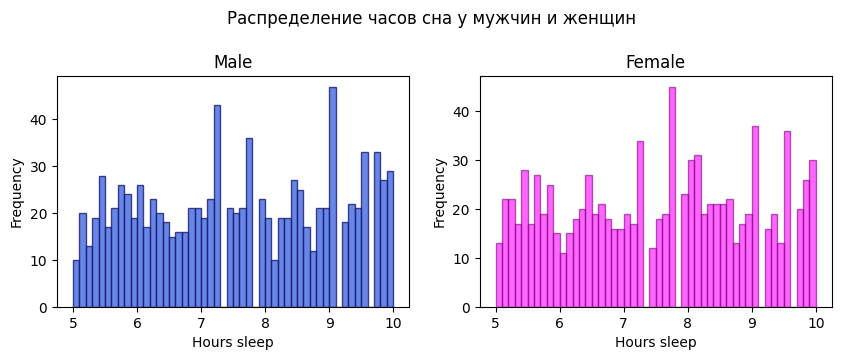

In [115]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle('Распределение часов сна у мужчин и женщин', fontsize=12, y=1.1)

axes[0].hist(male_sleep, bins=50, alpha=0.8, color='royalblue', edgecolor='midnightblue')
axes[0].set_title('Male')
axes[0].set_xlabel('Hours sleep')
axes[0].set_ylabel('Frequency')

axes[1].hist(female_sleep, bins=50, alpha=0.6, color='magenta', edgecolor='purple')
axes[1].set_title('Female')
axes[1].set_xlabel('Hours sleep')
axes[1].set_ylabel('Frequency')


По графикам очень заметно, что данные не распределены нормально

> ***Я решила не искать другие данные, а попытаться дойти до конца с этими и изучить доп тесты***

Для дальнейшего анализа выберу **Bootstrap-тест** (в отличии от U-критерия Манна-Уитни, который также не требует нормальности распределений, bootstrap позволяет сравнивать *именно средние* *)

##### **Критерии применимости bootstrap-теста**

+ независимость данных (соблюдается)
+ достаточный размер выборки (соблюдается, $n_{male} = 1016$, $n_{female} = 984$)
+ выборка отражает генеральную совокупность (соблюдается)
+ отсутствие существенных выбросов (визуально соблюдается, но лучше проверить)

Bootstrap может быть чувствителен к сильно разным дисперсиям и крайней асимметрии, но в данном случае, исходя из преданализа выше (дисперсии, графики), bootstrap должен работать корректно

\* H₀ и H₁ соответственно сохраняются в прежней формулировке

In [116]:
# проверка на выбросы

def outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outliers_male, lb_m, ub_m = outliers(male_sleep)
outliers_female, lb_f, ub_f = outliers(female_sleep)

print(f"Male: {outliers_male} выбросов ({outliers_male/len(male_sleep)*100:.3f}%)")
print(f"Female: {outliers_female} выбросов ({outliers_female/len(female_sleep)*100:.3f}%)")


Male: 0 выбросов (0.000%)
Female: 0 выбросов (0.000%)


Количество выбросов (0% < 5%) в допустимом для bootstrap-теста количестве, значит можно будет использовать стандартный (а не устойчивый к выбросам bootstrap-тест)

In [117]:
from sklearn.utils import resample

# bootstrap-тест для сравнения средних двух групп
def bootstrap_mean_test(group1, group2, n=10000, ci_level=0.95): # доверительный интервал
    observed_diff = np.mean(group1) - np.mean(group2)
    conc = np.concatenate([group1, group2])
    
    bootstrap_diffs = []
    
    for i in range(n):
        sample1 = resample(conc, n_samples=len(group1), replace=True, random_state=i)
        sample2 = resample(conc, n_samples=len(group2), replace=True, random_state=i + 10000)

        bootstrap_diff = np.mean(sample1) - np.mean(sample2)
        bootstrap_diffs.append(bootstrap_diff)
    
    bootstrap_diffs = np.array(bootstrap_diffs)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

    alpha = 1 - ci_level
    ci_lower = np.percentile(bootstrap_diffs, 100 * alpha/2)
    ci_upper = np.percentile(bootstrap_diffs, 100 * (1 - alpha/2))
    
    return observed_diff, p_value, bootstrap_diffs, ci_lower, ci_upper


# запуск bootstrap-теста
observed_diff, p_value, bootstrap_diffs, ci_lower, ci_upper = bootstrap_mean_test(male_sleep, female_sleep, n=10000)

print(f"Наблюдаемая разница средних Male -- Female: {observed_diff:.3f}")
print(f"Bootstrap p-value: {p_value:.3f}")

Наблюдаемая разница средних Male -- Female: 0.050
Bootstrap p-value: 0.448


По результатам теста $p_{value} = 0.448 > \alpha = 0.05$ -- значительно больше уровня статистической значимости $\alpha$, а значим мы **не отвергаем** нулевую гипотезу. То есть действительно

> #### **Среднее количество часов сна в сутки у студентов мужского и женского пола одинаково**